# 01. Seq2Point Windowing Artifact and Pseudo-PVR

Seq2Point SOC estimation is the old intuitive baseline: take a local window of voltage, current, and temperature, then regress one SOC value. It looks harmless because each prediction is only a scalar. For Battery Management Systems, that scalar output is the problem.

A discharge trajectory is not a bag of independent points. For discharge current, physical SOC must be non-increasing over time. A Seq2Point model emits `y_hat_t = f(x_{t-k:t+k})` independently at each center time, so the training loss has no native variable representing `y_hat_{t+1} - y_hat_t`. The model can minimize pointwise MSE while producing local upward jumps. Those jumps become a pseudo-trajectory only after post-hoc stitching, and the stitched curve has no structural monotonicity guarantee.

Overlapping windows make the artifact worse. Two adjacent windows can share most raw samples but still produce independently jittered scalar predictions. When plotted as a time series, the result looks like a trajectory, but it is only a sequence of independent local regressions. That is why Seq2Point cannot certify Physics Violation Rate (PVR) inside a discharge window.


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing src/ and data/.')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIG_DIR = ROOT / 'outputs' / 'figures' / 'ablation_studies'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'legend.fontsize': 8.5,
    'legend.frameon': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '-',
    'lines.linewidth': 1.8,
    'lines.markersize': 5,
})

print(f'Project root: {ROOT}')
print(f'Figure output: {FIG_DIR}')


Project root: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC
Figure output: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies


## Historical context ledger

The repository no longer keeps a dedicated Seq2Point checkpoint. The surviving historical ledger still records the important failure family: unconstrained point/sequence regressors produced nonzero PVR because the output topology did not encode discharge monotonicity. The synthetic experiment below isolates the specific Seq2Point stitching artifact without pretending to recover a deleted checkpoint.


In [2]:
legacy_path = ROOT / 'logs' / 'sprint44_results_v3.json'
if legacy_path.exists():
    legacy = json.loads(legacy_path.read_text(encoding='utf-8'))
    legacy_df = pd.DataFrame(legacy['results'])
    cols = ['model', 'scenario', 'rmse_pct', 'max_error_pct', 'pvr', 'n_violations', 'n_discharge']
    legacy_df = legacy_df[cols].copy()
    for col in ['rmse_pct', 'max_error_pct', 'pvr']:
        legacy_df[col] = legacy_df[col].astype(float)
    display(legacy_df.round({'rmse_pct': 3, 'max_error_pct': 3, 'pvr': 3}))
else:
    print(f'Legacy log missing: {legacy_path}')


,model,scenario,rmse_pct,max_error_pct,pvr,n_violations,n_discharge
0,LSTM,Scenario_A,12.571,81.743,50.484,1851089,3666702
1,TCN,Scenario_A,49.843,94.352,22.117,810968,3666702
2,PI-TCN,Scenario_A,40.992,89.556,17.021,624113,3666702
3,LSTM,Scenario_B,6.186,52.747,45.185,323874,716775
4,TCN,Scenario_B,5.483,55.858,50.546,362304,716775
5,PI-TCN,Scenario_B,6.788,54.949,43.626,312702,716775


## Synthetic Seq2Point pseudo-trajectory

The cell below simulates a physically valid discharge trajectory and a Seq2Point-style stitched prediction. The model is intentionally not given a recurrent or cumulative state. Each point prediction receives an independent local bias, so the post-hoc trajectory can rise during discharge even when the true SOC smoothly falls.


In [3]:
rng = np.random.default_rng(42)
t = np.arange(0, 160)
true_soc = 82.0 - 0.055 * t
window = 24
stride = 4
centers = np.arange(window // 2, len(t) - window // 2, stride)

low_frequency_bias = 0.42 * np.sin(centers / 5.0)
window_specific_noise = rng.normal(0.0, 0.28, size=len(centers))
seq2point_pred = true_soc[centers] + low_frequency_bias + window_specific_noise

delta_pred = np.diff(seq2point_pred)
violation_mask = delta_pred > 0.0
pseudo_pvr = float(violation_mask.sum() / delta_pred.size * 100.0)
rmse = float(np.sqrt(np.mean((seq2point_pred - true_soc[centers]) ** 2)))

artifact_df = pd.DataFrame({
    'Metric': ['Pseudo-PVR during discharge', 'Upward jumps', 'Trajectory steps', 'RMSE vs true SOC'],
    'Value': [f'{pseudo_pvr:.2f}%', int(violation_mask.sum()), int(delta_pred.size), f'{rmse:.3f} SOC pct'],
})
display(artifact_df)
assert violation_mask.sum() > 0, 'Synthetic Seq2Point artifact failed to produce monotonicity violations.'


,Metric,Value
0,Pseudo-PVR during discharge,24.24%
1,Upward jumps,8
2,Trajectory steps,33
3,RMSE vs true SOC,0.370 SOC pct


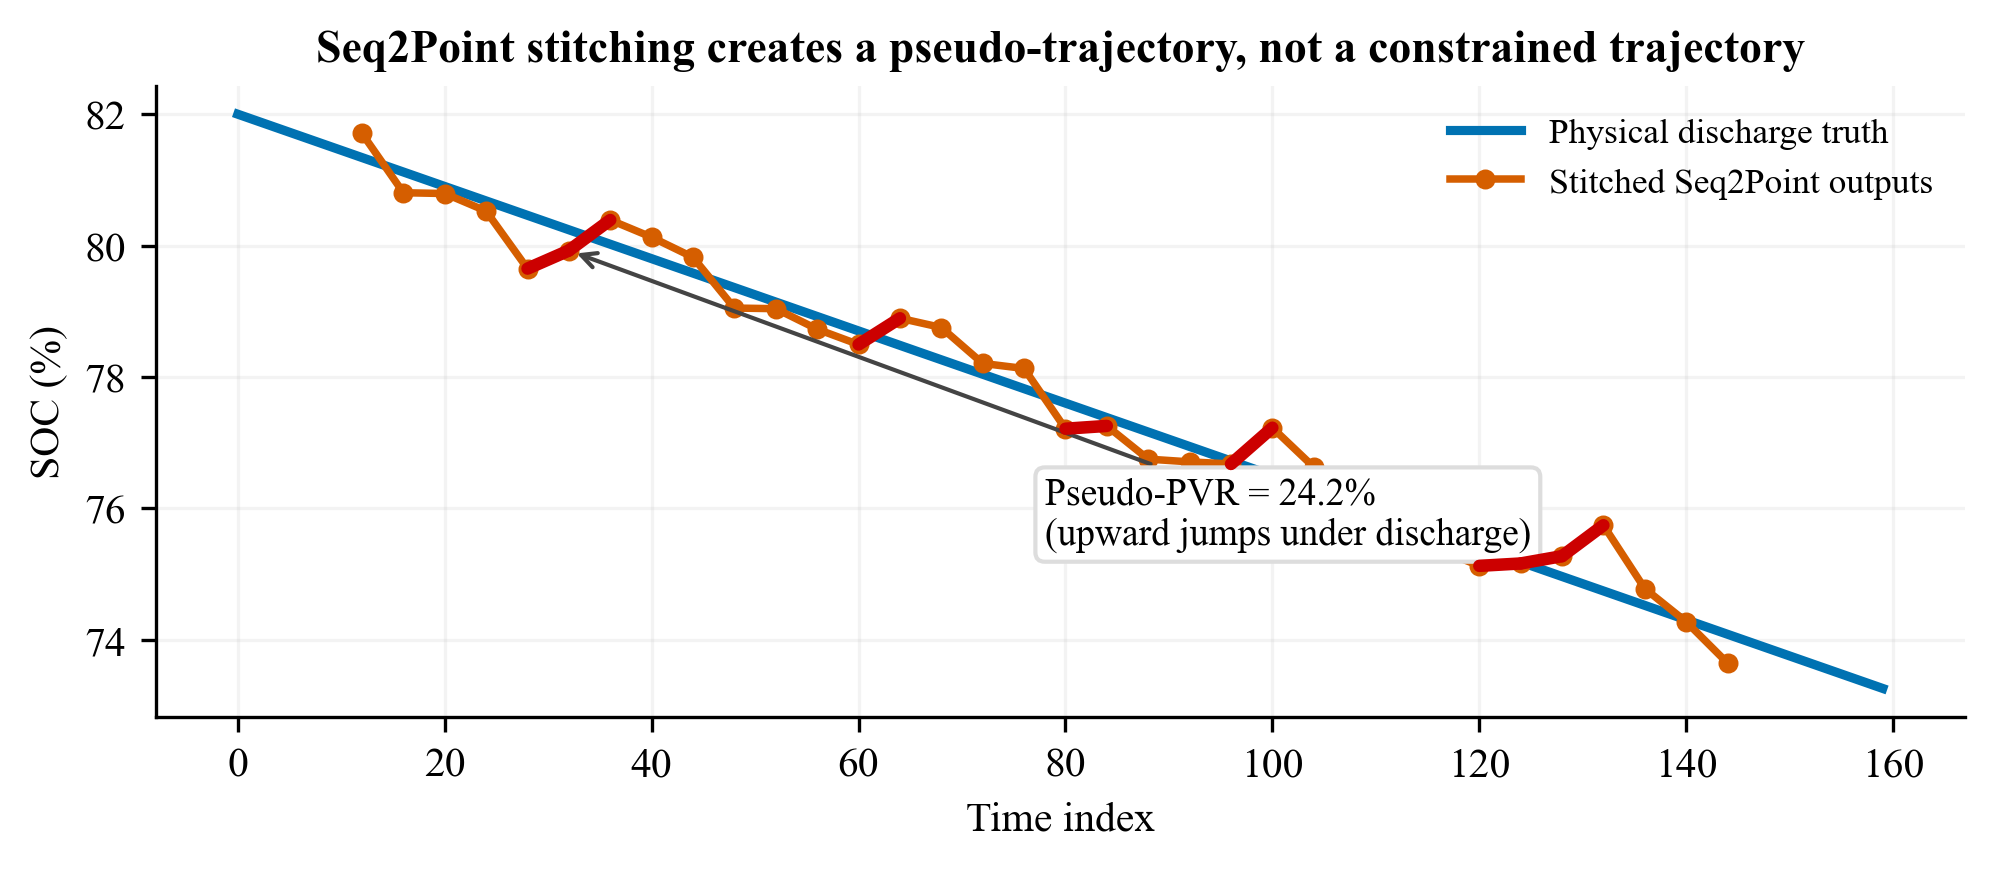

Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_01_seq2point_pseudo_pvr.pdf
Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_01_seq2point_pseudo_pvr.png


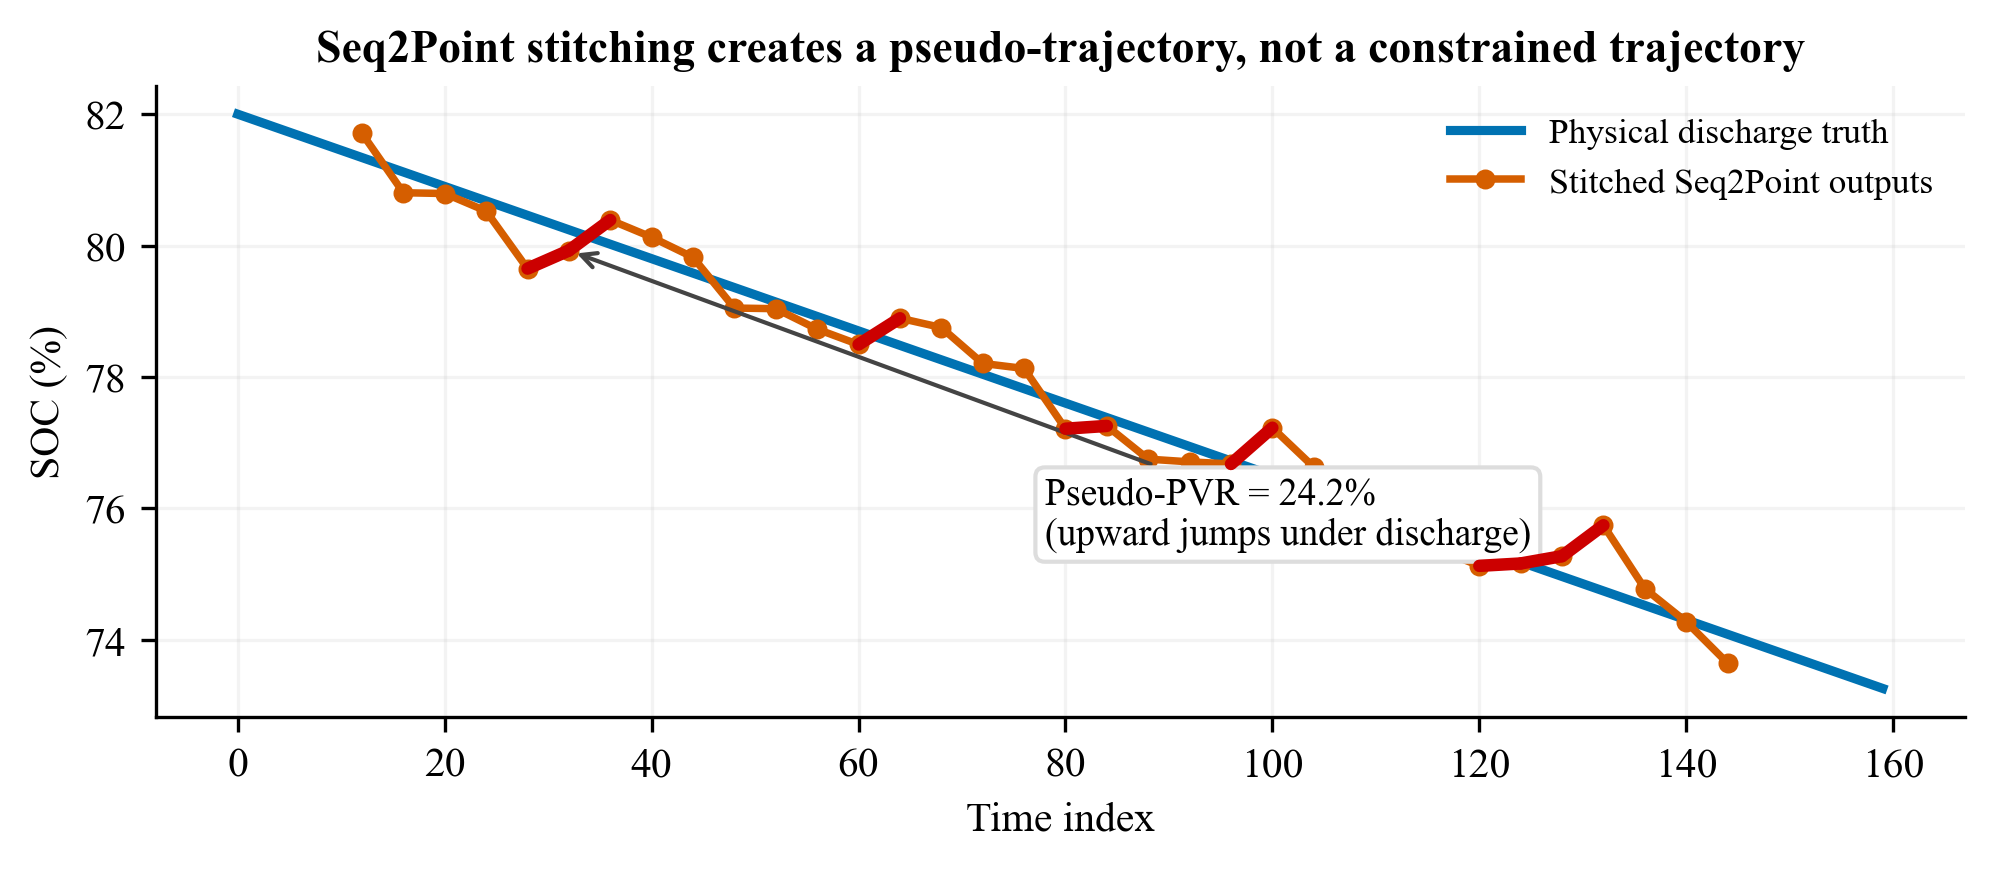

In [4]:
fig, ax = plt.subplots(figsize=(6.75, 3.0))
ax.plot(t, true_soc, color='#0072B2', label='Physical discharge truth', linewidth=2.2)
ax.plot(centers, seq2point_pred, color='#D55E00', marker='o', markersize=3.8, label='Stitched Seq2Point outputs')

for i, is_bad in enumerate(violation_mask):
    if not is_bad:
        continue
    ax.plot(
        centers[i:i+2],
        seq2point_pred[i:i+2],
        color='#CC0000',
        linewidth=3.0,
        solid_capstyle='round',
        zorder=5,
    )

ax.annotate(
    f'Pseudo-PVR = {pseudo_pvr:.1f}%\n(upward jumps under discharge)',
    xy=(centers[np.where(violation_mask)[0][0] + 1], seq2point_pred[np.where(violation_mask)[0][0] + 1]),
    xytext=(78, true_soc.min() + 2.2),
    arrowprops={'arrowstyle': '->', 'color': '#444444', 'lw': 1.0},
    fontsize=9,
    bbox={'boxstyle': 'round,pad=0.25', 'facecolor': 'white', 'edgecolor': '#DDDDDD'},
)
ax.set_xlabel('Time index')
ax.set_ylabel('SOC (%)')
ax.set_title('Seq2Point stitching creates a pseudo-trajectory, not a constrained trajectory')
ax.legend(loc='upper right')
fig.tight_layout()
pdf_path = FIG_DIR / 'fig_01_seq2point_pseudo_pvr.pdf'
png_path = FIG_DIR / 'fig_01_seq2point_pseudo_pvr.png'
fig.savefig(pdf_path)
fig.savefig(png_path, dpi=300)
display(fig)
print(f'Saved: {pdf_path}')
print(f'Saved: {png_path}')


## Autopsy

Seq2Point fails as a safety architecture because monotonicity is a relation between adjacent outputs, while the model emits independent scalar estimates. Any monotonicity check is therefore an external post-processing audit, not a structural property. A Hard-Coulomb sequence model fixes the topology: it predicts an anchor plus a constrained cumulative sum of current-routed SOC increments, so intra-window physical direction is part of the forward pass.
